In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amineipad/antenna-performance-and-fault-detection-dataset/antenna_fault.csv


## Problem Statement

Wearable antennas are used in many technologies such as IoT devices, smart clothing, healthcare monitors, and wireless communication systems. However, these antennas can sometimes develop faults due to problems in design, materials, bending, or manufacturing.

When a fault occurs, the antenna may show low signal strength, poor efficiency, or high signal loss, which affects wireless communication.

The goal of this project is to use machine learning to automatically detect antenna faults based on different antenna characteristics.

**The dataset includes several types of features:**

- Physical dimensions: Length, Width, Height

- Material properties: Permittivity, Conductivity, εr

- Structural parameters: Bend, Feed

- RF performance metrics: S11, VSWR, Gain, Efficiency, Bandwidth

Using these features, we train machine learning models to predict the type of WiFi antenna fault accurately.


## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style="whitegrid")

##  LOAD DATASET

In [3]:
path = "/kaggle/input/datasets/amineipad/antenna-performance-and-fault-detection-dataset/antenna_fault.csv"
df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (2688, 17)
   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

  WiFi Status BT Status  epsilon_r  
0       Fault     Fault       3.90  
1   

## DATA CLEANING

**Before analysis:**

- Missing numeric values are filled with the median.

- Target labels are encoded with LabelEncoder.

- ``` df[target] = le.fit_transform(df[target]) ```

```This ensures our ML algorithms can process the data without errors.```

In [4]:
# Fill missing numeric values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode target
target = "WiFi Fault"
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Length        2688 non-null   float64
 1   Width         2688 non-null   float64
 2   Height        2688 non-null   float64
 3   Permittivity  2688 non-null   float64
 4   Conductivity  2688 non-null   float64
 5   Bend          2688 non-null   float64
 6   Feed          2688 non-null   float64
 7   S11           2688 non-null   float64
 8   VSWR          2688 non-null   float64
 9   Gain          2688 non-null   float64
 10  Efficiency    2688 non-null   float64
 11  Bandwidth     2688 non-null   float64
 12  WiFi Fault    2688 non-null   int64  
 13  BT Fault      2688 non-null   object 
 14  WiFi Status   2688 non-null   object 
 15  BT Status     2688 non-null   object 
 16  epsilon_r     2688 non-null   float64
dtypes: float64(13), int64(1), object(3)
memory usage: 357.1+ KB
None


## EXPLORATORY DATA ANALYSIS 

We start with simple visualizations to understand distributions and correlations:

- **Class Distribution:** shows imbalance among fault types.

- **Correlation Heatmap:** reveals relationships between physical parameters and RF metrics.

- **Scatter Plot (Gain vs S11):** highlights clusters of fault conditions.

```At this stage, we can identify strong correlations and potential feature redundancies.```

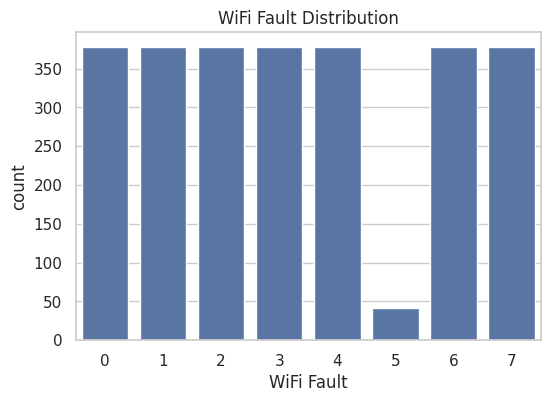

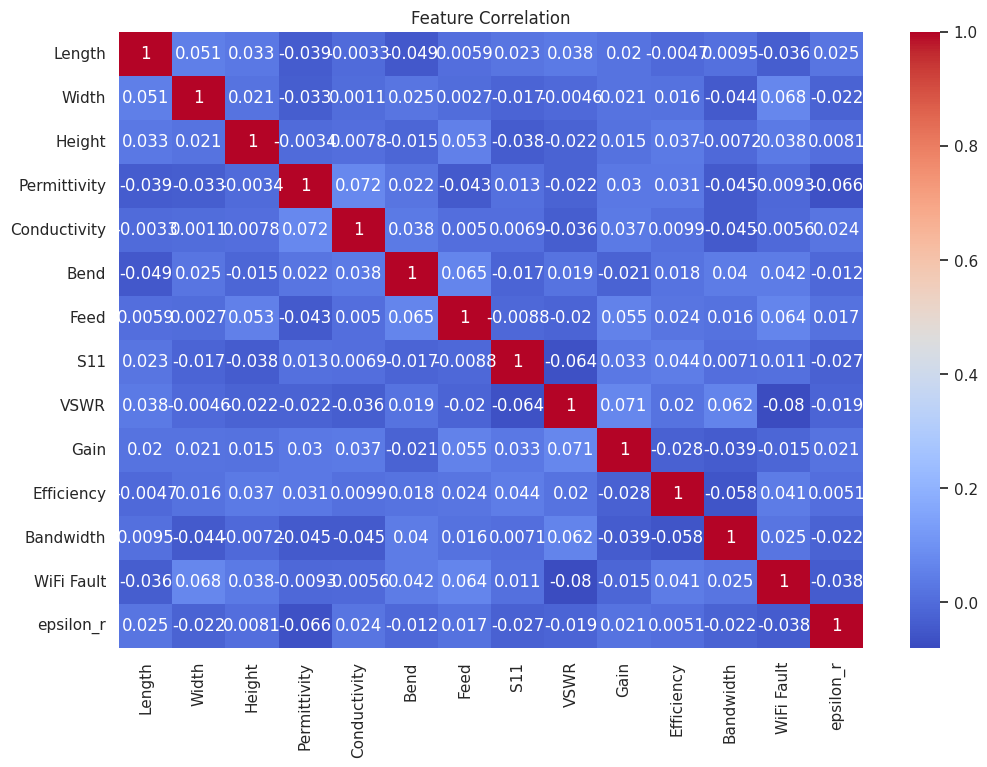

In [5]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("WiFi Fault Distribution")
plt.show()

# Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation")
plt.show()

# Scatter plot
fig = px.scatter(df, x="Gain", y="S11", color=target,
                 hover_data=["Length","Width","Height"],
                 title="Gain vs S11")
fig.show()


##  FEATURE SELECTION

In [6]:
features = ['Length','Width','Height','Permittivity','Conductivity',
            'Bend','Feed','S11','VSWR','Gain','Efficiency','Bandwidth','epsilon_r']

X = df[features]
y = df[target]

## FEATURE SCALING

```Standardization is particularly important for PCA and distance-based algorithms like SVM and KMeans.```

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA VISUALIZATION

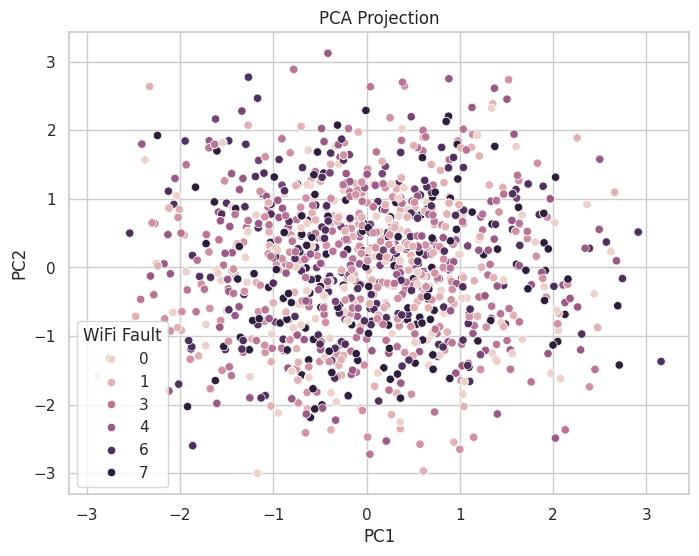

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1",y="PC2",hue=target,data=df)
plt.title("PCA Projection")
plt.show()

##  KMEANS CLUSTERING

In [9]:
kmeans = KMeans(n_clusters=8,random_state=42,n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

fig = px.scatter(df,x="PC1",y="PC2",color="Cluster",
                 hover_data=features,
                 title="KMeans Clusters")
fig.show()

## HANDLE CLASS IMBALANCE

In [10]:
smote = SMOTE(random_state=42)
X_res,y_res = smote.fit_resample(X_scaled,y)


## TRAIN TEST SPLIT

In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    X_res,y_res,test_size=0.2,random_state=42
)

## MODELS

**We choose five strong ML models:**

We use multiple strong ML models (Random Forest, XGBoost, LightGBM, CatBoost, and SVM) to compare their performance on antenna fault detection. Hyperparameter tuning with RandomizedSearchCV helps find the best settings for each model and improves prediction accuracy


In [12]:
models = {
"Random Forest":RandomForestClassifier(random_state=42),
"XGBoost":XGBClassifier(use_label_encoder=False,eval_metric="mlogloss"),
"LightGBM":LGBMClassifier(),
"CatBoost":CatBoostClassifier(verbose=0),
"SVM":SVC()
}

param_grids = {

"Random Forest":{
"n_estimators":[100,200,300],
"max_depth":[10,15,20]
},

"XGBoost":{
"n_estimators":[100,200],
"max_depth":[3,5,7],
"learning_rate":[0.05,0.1]
},

"LightGBM":{
"n_estimators":[100,200],
"max_depth":[5,10],
"learning_rate":[0.05,0.1]
},

"CatBoost":{
"iterations":[100,200],
"depth":[4,6],
"learning_rate":[0.05,0.1]
},

"SVM":{
"C":[0.1,1,10],
"kernel":["linear","rbf"]
}

}


##  MODEL TRAINING + TUNING

In [13]:
results=[]
best_models={}

for name,model in models.items():

    print("\nTraining:",name)

    grid = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=5,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train,y_train)

    best_models[name] = grid.best_estimator_

    preds = grid.predict(X_test)

    acc = accuracy_score(y_test,preds)

    results.append({
        "Model":name,
        "Accuracy":acc
    })

    print("Accuracy:",acc)
    print(classification_report(y_test,preds))


Training: Random Forest
Accuracy: 0.8760330578512396
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        68
           1       0.92      0.84      0.88        85
           2       0.94      0.83      0.88        92
           3       0.75      0.91      0.82        65
           4       0.84      0.87      0.85        76
           5       1.00      1.00      1.00        67
           6       0.82      0.84      0.83        69
           7       0.94      0.87      0.90        83

    accuracy                           0.88       605
   macro avg       0.88      0.88      0.88       605
weighted avg       0.88      0.88      0.88       605


Training: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:50] WARNING: /w

Accuracy: 0.8793388429752066
              precision    recall  f1-score   support

           0       0.74      0.90      0.81        68
           1       0.90      0.88      0.89        85
           2       0.88      0.80      0.84        92
           3       0.83      0.89      0.86        65
           4       0.92      0.91      0.91        76
           5       1.00      1.00      1.00        67
           6       0.84      0.83      0.83        69
           7       0.93      0.86      0.89        83

    accuracy                           0.88       605
   macro avg       0.88      0.88      0.88       605
weighted avg       0.88      0.88      0.88       605


Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3068
[LightGBM] [Info] Number of data points in the train set: 1935, number of used features: 13
[LightGBM] [

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## MODEL COMPARISON

In [14]:
results_df = pd.DataFrame(results)
print(results_df)

best_model_name = results_df.sort_values(
    by="Accuracy",ascending=False
).iloc[0]["Model"]

print("Best Model:",best_model_name)

best_model = best_models[best_model_name]

           Model  Accuracy
0  Random Forest  0.876033
1        XGBoost  0.879339
2       LightGBM  0.884298
3       CatBoost  0.834711
4            SVM  0.876033
Best Model: LightGBM


## CONFUSION MATRIX

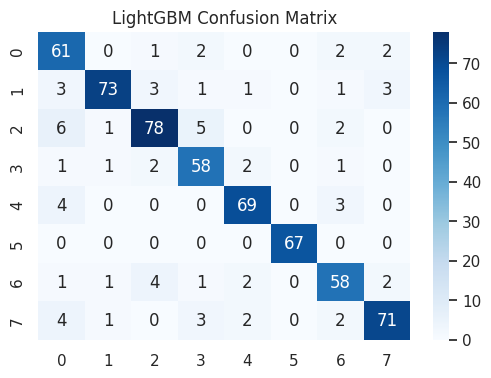

In [15]:
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test,preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title(best_model_name+" Confusion Matrix")
plt.show()

## SHAP FEATURE IMPORTANCE

100%|===================| 3996/4000 [03:44<00:00]       

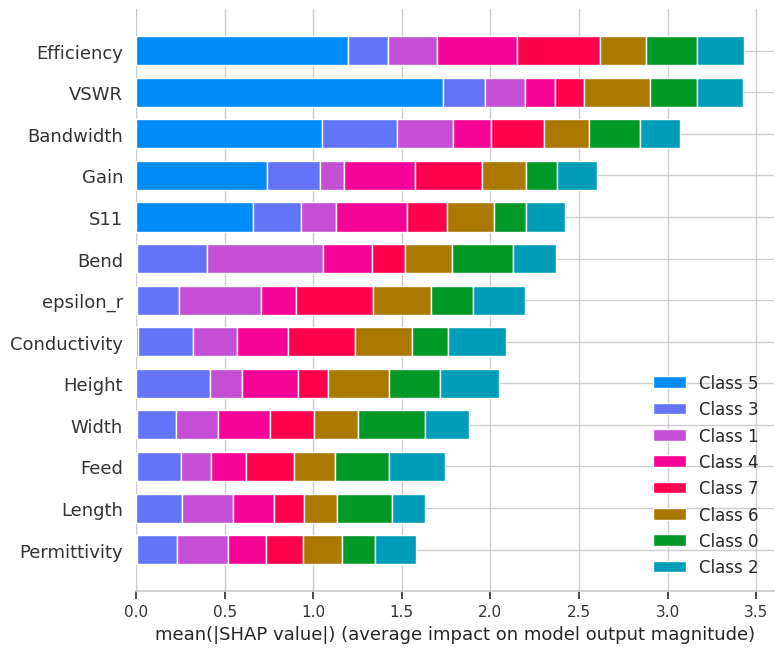

In [16]:
explainer = shap.Explainer(best_model,X_train)
shap_values = explainer(X_train[:500])

shap.summary_plot(
    shap_values,
    features=X_train[:500],
    feature_names=features
)

#  Overall Overview

In this project, we built a **machine learning pipeline to detect wearable antenna faults** using physical, material, and RF performance features.

First, the dataset was **cleaned and explored** using visualizations to understand feature relationships. Then **PCA** was applied for dimensionality reduction and **KMeans** was used to explore natural clusters in the data.

To address class imbalance, **SMOTE** was used before training multiple machine learning models including **Random Forest, XGBoost, LightGBM, CatBoost, and SVM**. Hyperparameters were tuned using **RandomizedSearchCV** with cross-validation.

Among all models, achieved the best performance (~88% accuracy). Finally, **SHAP** was used to interpret the model and identify the most important features affecting antenna fault detection.

Overall, the results show that **ensemble tree-based models are highly effective for predicting antenna faults**.